# CS506 Final Project

## 1. Load Cache & Imports

In [1]:
!pip install rank-bm25 implicit kagglehub


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for implicit: filename=implicit-0.7.2-cp312-cp312-linux_x86_64.whl size=933264 sha256=960490bf0f7b3c65471f10d385bd90a6e873d72cf1d43499ab60033dab5a52cb
  Stored in directory: /root/.cache/pip/wheels/b2/00/4f/9ff8af07a0a53ac6007ea5d739da19cfe147a2df542b6899f8
Successfully built implicit


In [2]:
import os
os.environ['KAGGLE_USERNAME'] = 'robotx95'
os.environ['KAGGLE_KEY'] = 'KGAT_8e99056c5f756b606cd96fcf6e1f5860'


In [3]:
import os
# import pickle  # pickle cache no longer used — objects rebuilt from filtered directly
import math, time
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from collections import defaultdict
from rank_bm25 import BM25Okapi
import implicit
from sklearn.decomposition import TruncatedSVD

# CACHE_PATH    = "preprocessed_cache.parquet"
# CACHE_OBJECTS = "preprocessed_objects.pkl"

# assert os.path.exists(CACHE_PATH) and os.path.exists(CACHE_OBJECTS), (
#     "Cache files not found — run preprocessing.ipynb first."
# )

# filtered = pd.read_parquet(CACHE_PATH)

# with open(CACHE_OBJECTS, "rb") as f:
#     cache = pickle.load(f)

# train_playlist_to_songs = cache["train_playlist_to_songs"]
# test_playlist_to_songs  = cache["test_playlist_to_songs"]
# test_cases              = cache["test_cases"]
# song_display_map        = cache["song_display_map"]
# train_song_popularity   = cache["train_song_popularity"]
# popular_ranking         = cache["popular_ranking"]
# song_to_playlists       = cache["song_to_playlists"]
# playlist_song_set       = cache["playlist_song_set"]
# RANDOM_SEED, TOPK       = 42, 10

# plt.rcParams.update({
#     "figure.dpi": 130,
#     "axes.spines.top": False,
#     "axes.spines.right": False,
#     "axes.grid": True,
#     "grid.alpha": 0.3,
# })

# print(f"Loaded {len(filtered):,} rows | {len(test_cases):,} test cases")
# print(f"Train playlists: {len(train_playlist_to_songs):,} | Test playlists: {len(test_playlist_to_songs):,}")


import os
import csv
import re
import math
import time
import random
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Configuration
DATA_PATH = "spotify_dataset.csv"
MIN_PLAYLIST_SIZE = 5
MAX_PLAYLIST_SIZE = 500
MIN_SONG_FREQ = 3

In [4]:
def clean_col(c: str) -> str:
    c = str(c).strip()
    if c.startswith('"') and c.endswith('"') and len(c) >= 2:
        c = c[1:-1].strip()
    return c

def robust_load_csv(path: str) -> pd.DataFrame:
    """Load CSV, dropping rows with wrong number of columns."""
    with open(path, "r", encoding="utf-8", errors="replace", newline="") as f:
        header_line = f.readline().rstrip("\n")
    raw_header = next(csv.reader([header_line], delimiter=",", quotechar='"', escapechar="\\"))
    expected_cols = len(raw_header)
    header = [clean_col(c) for c in raw_header]

    good_rows, bad_count = [], 0
    with open(path, "r", encoding="utf-8", errors="replace", newline="") as f:
        reader = csv.reader(f, delimiter=",", quotechar='"', escapechar="\\")
        next(reader)  # skip header
        for row in reader:
            if len(row) == expected_cols:
                good_rows.append(row)
            else:
                bad_count += 1

    df = pd.DataFrame(good_rows, columns=header)
    print(f"Loaded shape: {df.shape}")
    print(f"Malformed rows dropped: {bad_count}")
    print(f"Columns: {list(df.columns)}")
    return df

# Download data if needed
if not os.path.exists(DATA_PATH):
    print("Data file not found. Run: python download_data.py")
else:
    raw_df = robust_load_csv(DATA_PATH)
    raw_df.head()

Loaded shape: (617647, 4)
Malformed rows dropped: 428
Columns: ['user_id', 'artistname', 'trackname', 'playlistname']


## 1b. Raw Data Exploration

Before any cleaning or filtering, let's understand the raw dataset:
- **Shape & missing values** — how complete is the data?
- **Distributions** — how are playlists, songs, and artists spread out?
- **Top entities** — which artists/tracks/playlists dominate?

In [5]:
# --- Quick overview of the raw dataset ---
print("="*50)
print("RAW DATASET OVERVIEW")
print("="*50)
print(f"Shape : {raw_df.shape[0]:,} rows  x  {raw_df.shape[1]} columns")
print(f"Columns: {list(raw_df.columns)}")
print()

# Missing / empty values per column
print("Missing or empty values per column:")
for col in raw_df.columns:
    n_null  = raw_df[col].isna().sum()
    n_empty = (raw_df[col].astype(str).str.strip() == "").sum()
    print(f"  {col:20s}  null={n_null:,}   empty_string={n_empty:,}")
print()

# Basic unique counts
print(f"Unique users      : {raw_df['user_id'].nunique():,}")
print(f"Unique artists    : {raw_df['artistname'].nunique():,}")
print(f"Unique tracks     : {raw_df['trackname'].nunique():,}")
print(f"Unique playlists  : {raw_df['playlistname'].nunique():,}")
print()

# Dtypes
print("Column dtypes:")
print(raw_df.dtypes.to_string())
print()

# First 5 rows
raw_df.head()

RAW DATASET OVERVIEW
Shape : 617,647 rows  x  4 columns
Columns: ['user_id', 'artistname', 'trackname', 'playlistname']

Missing or empty values per column:
  user_id               null=0   empty_string=0
  artistname            null=0   empty_string=1,173
  trackname             null=0   empty_string=8
  playlistname          null=0   empty_string=0

Unique users      : 899
Unique artists    : 48,073
Unique tracks     : 260,430
Unique playlists  : 10,658

Column dtypes:
user_id         object
artistname      object
trackname       object
playlistname    object



,user_id,artistname,trackname,playlistname
0,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,(The Angels Wanna Wear My) Red Shoes,HARD ROCK 2010
1,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,"(What's So Funny 'Bout) Peace, Love And Unders...",HARD ROCK 2010
2,9cc0cfd4d7d7885102480dd99e7a90d6,Tiffany Page,7 Years Too Late,HARD ROCK 2010
3,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,Accidents Will Happen,HARD ROCK 2010
4,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,Alison,HARD ROCK 2010


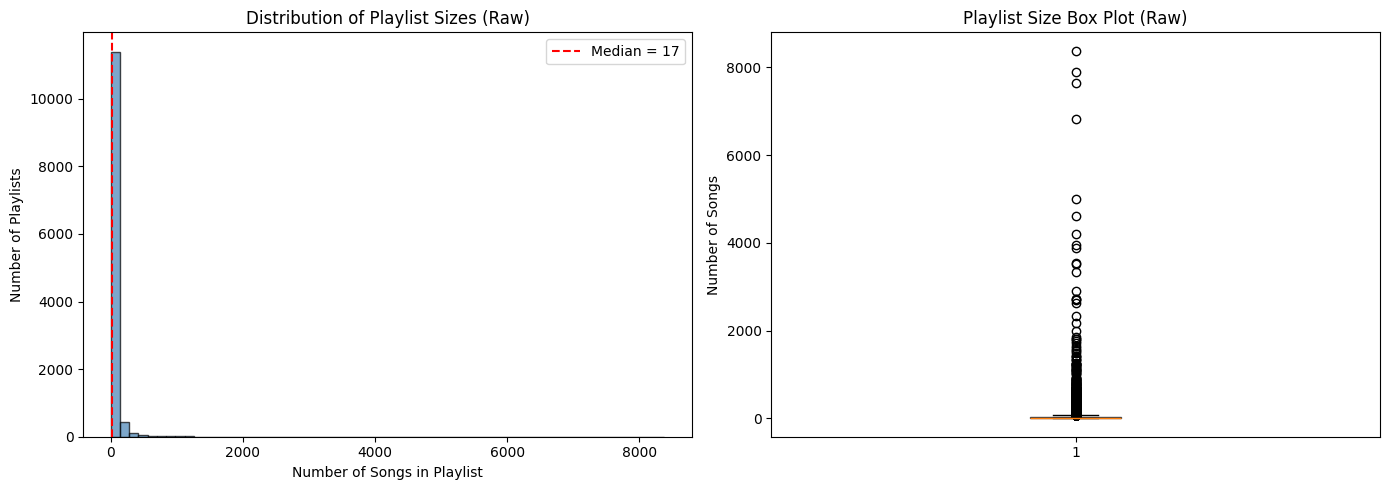

Playlist size stats:
count    12110.0
mean        51.0
std        212.0
min          1.0
25%         11.0
50%         17.0
75%         38.0
max       8378.0
Name: trackname, dtype: float64


In [6]:
# --- Visualization 1: Songs per playlist distribution (raw) ---
raw_playlist_sizes = raw_df.groupby(["user_id", "playlistname"])["trackname"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(raw_playlist_sizes.values, bins=60, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_xlabel("Number of Songs in Playlist")
axes[0].set_ylabel("Number of Playlists")
axes[0].set_title("Distribution of Playlist Sizes (Raw)")
axes[0].axvline(raw_playlist_sizes.median(), color="red", linestyle="--", label=f"Median = {raw_playlist_sizes.median():.0f}")
axes[0].legend()

# Box plot
axes[1].boxplot(raw_playlist_sizes.values, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_ylabel("Number of Songs")
axes[1].set_title("Playlist Size Box Plot (Raw)")

plt.tight_layout()
plt.show()

print(f"Playlist size stats:\n{raw_playlist_sizes.describe().round(1)}")

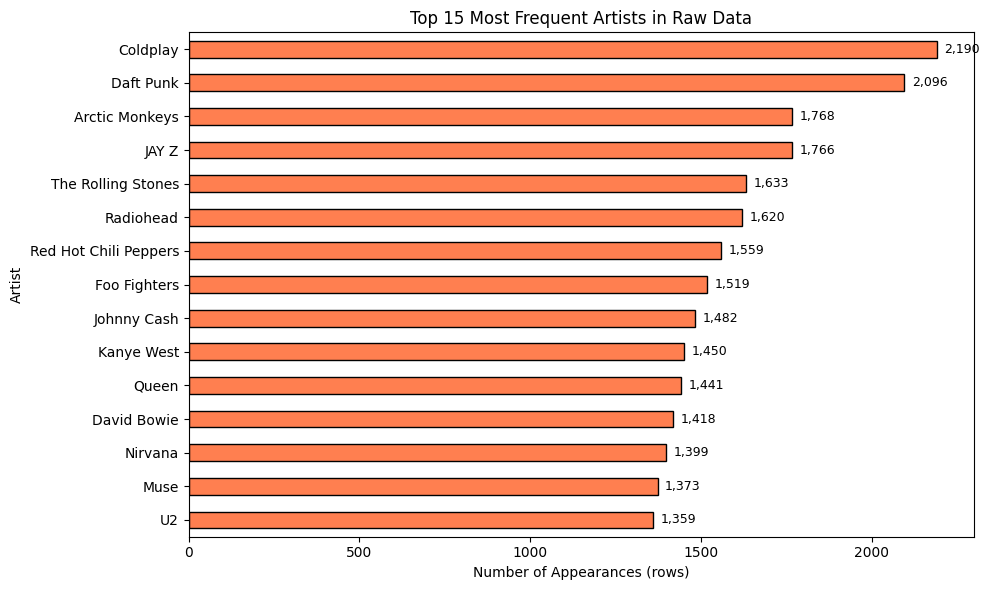

In [7]:
# --- Visualization 2: Top 15 Artists by track count ---
top_artists = raw_df["artistname"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top_artists.plot(kind="barh", color="coral", edgecolor="black", ax=ax)
ax.set_xlabel("Number of Appearances (rows)")
ax.set_ylabel("Artist")
ax.set_title("Top 15 Most Frequent Artists in Raw Data")
for i, (val, name) in enumerate(zip(top_artists.values, top_artists.index)):
    ax.text(val + max(top_artists.values)*0.01, i, f"{val:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

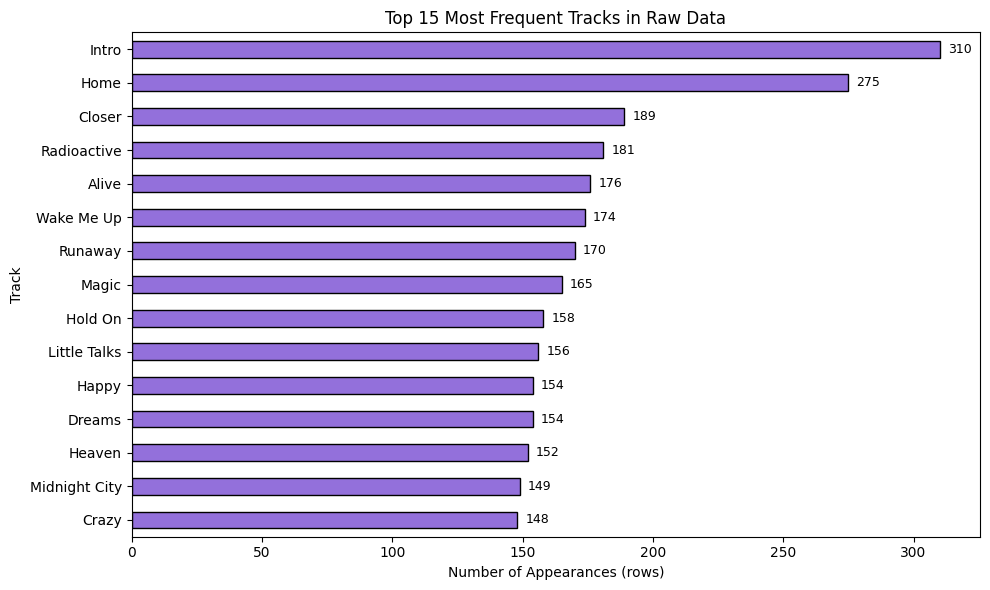

In [8]:
# --- Visualization 3: Top 15 Tracks by appearance count ---
top_tracks = raw_df["trackname"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top_tracks.plot(kind="barh", color="mediumpurple", edgecolor="black", ax=ax)
ax.set_xlabel("Number of Appearances (rows)")
ax.set_ylabel("Track")
ax.set_title("Top 15 Most Frequent Tracks in Raw Data")
for i, (val, name) in enumerate(zip(top_tracks.values, top_tracks.index)):
    ax.text(val + max(top_tracks.values)*0.01, i, f"{val:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

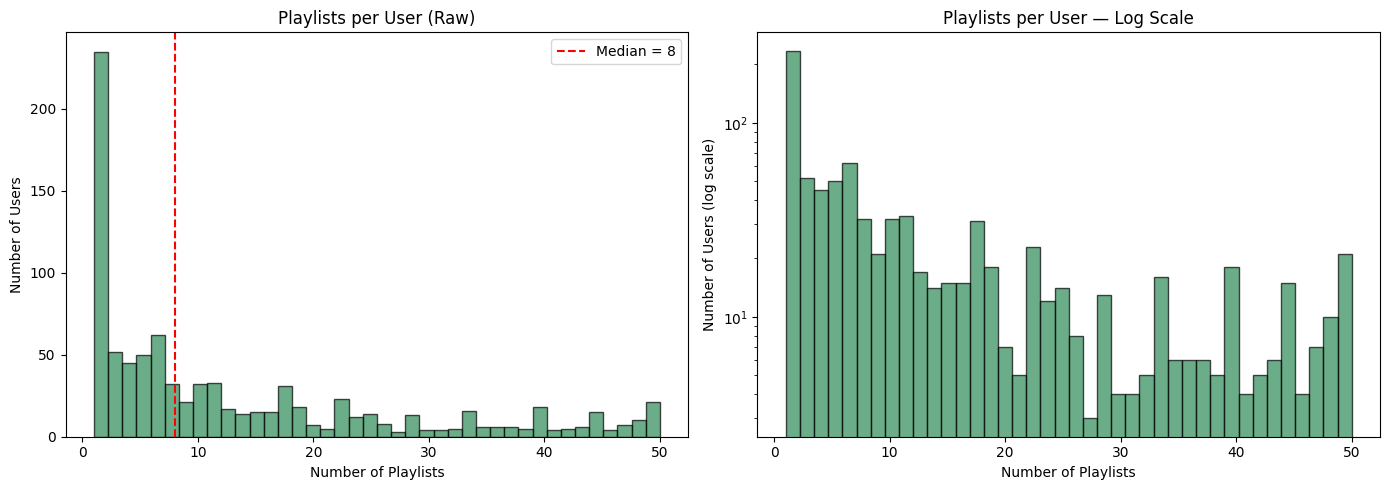

Playlists-per-user stats:
count    899.0
mean      13.5
std       14.0
min        1.0
25%        2.0
50%        8.0
75%       20.0
max       50.0
Name: playlistname, dtype: float64


In [9]:
# --- Visualization 4: Number of playlists per user ---
playlists_per_user = raw_df.groupby("user_id")["playlistname"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(playlists_per_user.values, bins=40, edgecolor="black", alpha=0.7, color="seagreen")
axes[0].set_xlabel("Number of Playlists")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("Playlists per User (Raw)")
axes[0].axvline(playlists_per_user.median(), color="red", linestyle="--", label=f"Median = {playlists_per_user.median():.0f}")
axes[0].legend()

# Log-scale version to see the tail
axes[1].hist(playlists_per_user.values, bins=40, edgecolor="black", alpha=0.7, color="seagreen")
axes[1].set_xlabel("Number of Playlists")
axes[1].set_ylabel("Number of Users (log scale)")
axes[1].set_title("Playlists per User — Log Scale")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Playlists-per-user stats:\n{playlists_per_user.describe().round(1)}")

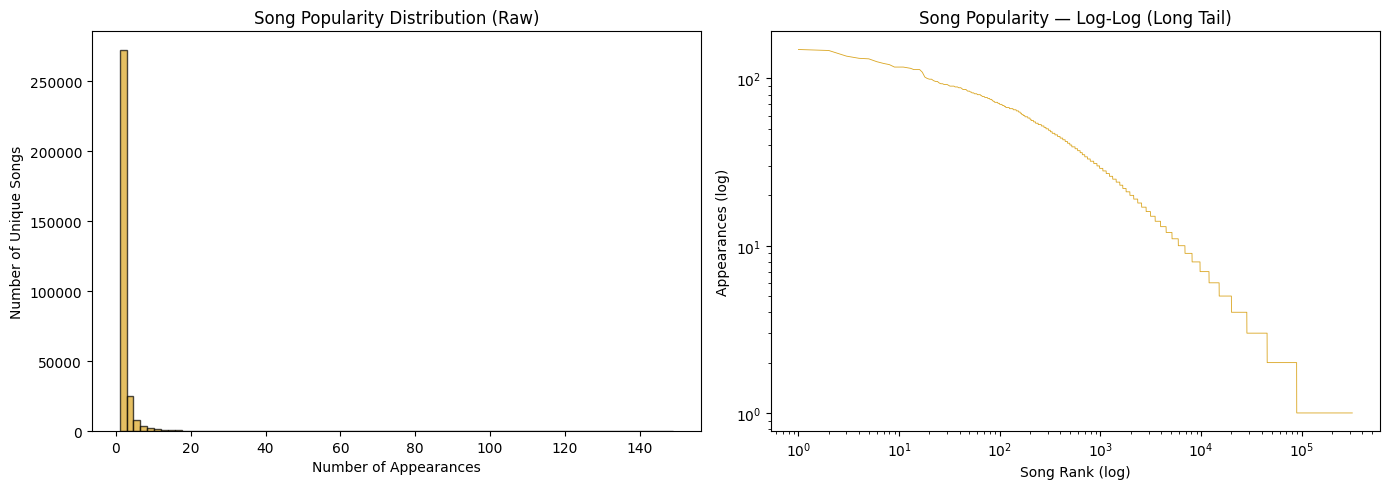

Total unique songs: 317,106
Songs appearing only once: 228,340 (72.0%)
Top 1% of songs account for 91,105 / 617,647 rows


In [10]:
# --- Visualization 5: Song popularity (long-tail) ---
# How many playlists does each unique (artist, track) appear in?
raw_song_key = raw_df["artistname"].astype(str) + " | " + raw_df["trackname"].astype(str)
song_popularity = raw_song_key.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(song_popularity.values, bins=80, edgecolor="black", alpha=0.7, color="goldenrod")
axes[0].set_xlabel("Number of Appearances")
axes[0].set_ylabel("Number of Unique Songs")
axes[0].set_title("Song Popularity Distribution (Raw)")

# Log-log scale — classic long-tail shape
rank = np.arange(1, len(song_popularity) + 1)
axes[1].loglog(rank, song_popularity.values, linewidth=0.6, color="goldenrod")
axes[1].set_xlabel("Song Rank (log)")
axes[1].set_ylabel("Appearances (log)")
axes[1].set_title("Song Popularity — Log-Log (Long Tail)")

plt.tight_layout()
plt.show()

pct_once = (song_popularity == 1).sum() / len(song_popularity) * 100
print(f"Total unique songs: {len(song_popularity):,}")
print(f"Songs appearing only once: {(song_popularity == 1).sum():,} ({pct_once:.1f}%)")
print(f"Top 1% of songs account for {song_popularity.head(int(len(song_popularity)*0.01)).sum():,} / {song_popularity.sum():,} rows")

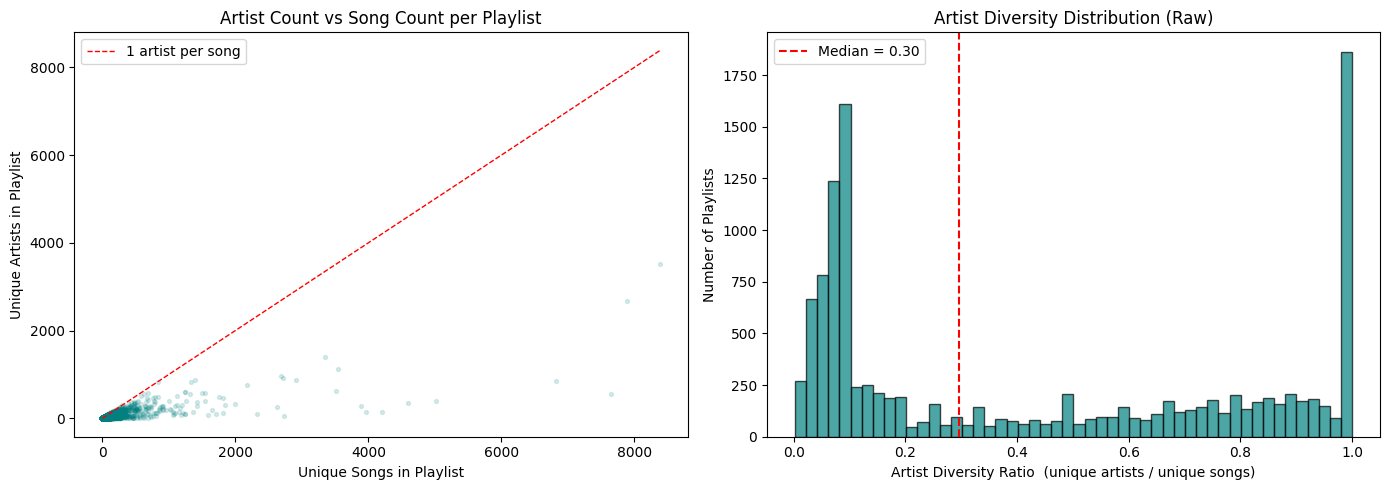

In [11]:
# --- Visualization 6: Artists per playlist vs Songs per playlist ---
raw_pl_group = raw_df.groupby(["user_id", "playlistname"])
songs_per_pl  = raw_pl_group["trackname"].nunique()
artists_per_pl = raw_pl_group["artistname"].nunique()

merged_pl = pd.DataFrame({"n_songs": songs_per_pl, "n_artists": artists_per_pl})
merged_pl["diversity"] = merged_pl["n_artists"] / merged_pl["n_songs"].clip(lower=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: songs vs artists
axes[0].scatter(merged_pl["n_songs"], merged_pl["n_artists"], alpha=0.15, s=8, color="teal")
axes[0].plot([0, merged_pl["n_songs"].max()], [0, merged_pl["n_songs"].max()],
             "r--", linewidth=1, label="1 artist per song")
axes[0].set_xlabel("Unique Songs in Playlist")
axes[0].set_ylabel("Unique Artists in Playlist")
axes[0].set_title("Artist Count vs Song Count per Playlist")
axes[0].legend()

# Histogram of diversity ratio
axes[1].hist(merged_pl["diversity"].values, bins=50, edgecolor="black", alpha=0.7, color="teal")
axes[1].set_xlabel("Artist Diversity Ratio  (unique artists / unique songs)")
axes[1].set_ylabel("Number of Playlists")
axes[1].set_title("Artist Diversity Distribution (Raw)")
axes[1].axvline(merged_pl["diversity"].median(), color="red", linestyle="--",
                label=f"Median = {merged_pl['diversity'].median():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
USER_COL = "user_id"
ARTIST_COL = "artistname"
TRACK_COL = "trackname"
PLAYLIST_COL = "playlistname"

def normalize_text(s: str) -> str:
    """Normalize text: lowercase, remove accents/special chars, collapse spaces."""
    if pd.isna(s):
        return ""
    s = str(s)
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower().strip()
    s = s.replace("&", " and ")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

work_df = raw_df.copy()
for col in [USER_COL, ARTIST_COL, TRACK_COL, PLAYLIST_COL]:
    work_df[col] = work_df[col].fillna("").astype(str)

work_df["artist_norm"] = work_df[ARTIST_COL].map(normalize_text)
work_df["track_norm"] = work_df[TRACK_COL].map(normalize_text)
work_df["song_key"] = work_df["artist_norm"] + " — " + work_df["track_norm"]
work_df["playlist_key"] = work_df[USER_COL].astype(str) + " :: " + work_df[PLAYLIST_COL].map(normalize_text)

# Remove empty/broken records
before = len(work_df)
work_df = work_df[
    (work_df["song_key"].str.strip() != "—") &
    (work_df["artist_norm"].str.strip() != "") &
    (work_df["track_norm"].str.strip() != "") &
    (work_df["playlist_key"].str.strip() != "")
].copy()
print(f"Removed empty/broken rows: {before - len(work_df):,}")

# Remove duplicate (playlist, song) pairs
before = len(work_df)
work_df = work_df.drop_duplicates(subset=["playlist_key", "song_key"], keep="first").copy()
print(f"Removed duplicate (playlist, song) rows: {before - len(work_df):,}")
print(f"\nCleaned dataset shape: {work_df.shape}")
print(f"Unique playlists: {work_df['playlist_key'].nunique():,}")
print(f"Unique songs: {work_df['song_key'].nunique():,}")
print(f"Unique users: {work_df[USER_COL].nunique():,}")

Removed empty/broken rows: 1,541
Removed duplicate (playlist, song) rows: 2,199

Cleaned dataset shape: (613907, 8)
Unique playlists: 12,080
Unique songs: 306,664
Unique users: 899


In [13]:
# Song popularity (number of playlists containing this song)
song_freq = work_df["song_key"].value_counts()
work_df["song_freq"] = work_df["song_key"].map(song_freq)

# Playlist size (unique songs per playlist)
playlist_size = work_df.groupby("playlist_key")["song_key"].nunique()
work_df["playlist_size"] = work_df["playlist_key"].map(playlist_size)

# Artist count per playlist
playlist_artist_count = work_df.groupby("playlist_key")["artist_norm"].nunique()
work_df["playlist_artist_count"] = work_df["playlist_key"].map(playlist_artist_count)

# Artist diversity ratio
work_df["artist_diversity_ratio"] = work_df["playlist_artist_count"] / work_df["playlist_size"].clip(lower=1)

# Filter playlists and songs
filtered = work_df[
    (work_df["playlist_size"] >= MIN_PLAYLIST_SIZE) &
    (work_df["playlist_size"] <= MAX_PLAYLIST_SIZE) &
    (work_df["song_freq"] >= MIN_SONG_FREQ)
].copy()

# Recompute sizes after song filtering and keep only playlists still large enough
filtered_playlist_size = filtered.groupby("playlist_key")["song_key"].nunique()
filtered = filtered[filtered["playlist_key"].isin(filtered_playlist_size.index)].copy()
filtered["playlist_size_filtered"] = filtered["playlist_key"].map(filtered_playlist_size)
filtered = filtered[filtered["playlist_size_filtered"] >= MIN_PLAYLIST_SIZE].copy()

print(f"Shape after filtering: {filtered.shape}")
print(f"Unique playlists: {filtered['playlist_key'].nunique():,}")
print(f"Unique songs: {filtered['song_key'].nunique():,}")
print(f"Unique users: {filtered[USER_COL].nunique():,}")

# Build playlist-level feature table
playlist_features = (
    filtered.groupby("playlist_key")
    .agg(
        user_id=(USER_COL, "first"),
        playlist_name=(PLAYLIST_COL, "first"),
        n_songs=("song_key", "nunique"),
        n_artists=("artist_norm", "nunique"),
        avg_song_popularity=("song_freq", "mean"),
    )
    .reset_index()
)
playlist_features["artist_diversity_ratio"] = playlist_features["n_artists"] / playlist_features["n_songs"].clip(lower=1)
print("\nPlaylist feature summary:")
playlist_features.describe().round(2)

Shape after filtering: (224104, 13)
Unique playlists: 7,055
Unique songs: 44,507
Unique users: 798

Playlist feature summary:


,n_songs,n_artists,avg_song_popularity,artist_diversity_ratio
count,7055.00,7055.00,7055.00,7055.00
mean,31.77,16.22,15.49,0.49
std,42.04,26.00,10.99,0.37
min,5.00,1.00,3.00,0.01
25%,10.00,1.00,7.06,0.10
50%,16.00,7.00,12.64,0.51
75%,35.00,19.00,21.00,0.85
max,430.00,305.00,97.80,1.00


In [14]:
# Build all cached objects directly from filtered (replaces preprocessed_objects.pkl)
TOPK = 10

# --- song_display_map: song_key → "Artist — Track" (original casing) ---
song_display_map = (
    filtered.drop_duplicates("song_key")
    .set_index("song_key")
    .apply(lambda r: f"{r[ARTIST_COL]} — {r[TRACK_COL]}", axis=1)
    .to_dict()
)

# --- Train / Test playlist split (80 / 20) ---
all_playlists = filtered["playlist_key"].unique().tolist()
rng_split = np.random.default_rng(RANDOM_SEED)
rng_split.shuffle(all_playlists)
n_test    = max(1, int(len(all_playlists) * 0.2))
test_pls  = set(all_playlists[:n_test])
train_pls = set(all_playlists[n_test:])

# --- playlist → song sets for train and test ---
train_df = filtered[filtered["playlist_key"].isin(train_pls)]
test_df  = filtered[filtered["playlist_key"].isin(test_pls)]

train_playlist_to_songs = (
    train_df.groupby("playlist_key")["song_key"].apply(set).to_dict()
)
test_playlist_to_songs = (
    test_df.groupby("playlist_key")["song_key"].apply(set).to_dict()
)

# --- song_to_playlists & playlist_song_set (train only) ---
song_to_playlists = defaultdict(set)
for pk, songs in train_playlist_to_songs.items():
    for s in songs:
        song_to_playlists[s].add(pk)

playlist_song_set = train_playlist_to_songs  # same dict; values are already sets

# --- train_song_popularity & popular_ranking ---
train_song_popularity = {s: len(pls) for s, pls in song_to_playlists.items()}
popular_ranking = sorted(train_song_popularity, key=lambda s: -train_song_popularity[s])

# --- test_cases: observed / hidden split per test playlist ---
rng_tc = np.random.default_rng(RANDOM_SEED + 1)
test_cases = []
for pk, songs in test_playlist_to_songs.items():
    song_list = sorted(songs)          # deterministic base order
    rng_tc.shuffle(song_list)
    n_hidden = max(1, len(song_list) // 5)   # hide ≈20 % of each playlist
    hidden   = set(song_list[:n_hidden])
    # only keep observed songs that also appear in training (required for lookup)
    observed = [s for s in song_list[n_hidden:] if s in train_song_popularity]
    if observed and hidden:
        test_cases.append({"observed": observed, "hidden": hidden})

print(f"Train playlists : {len(train_playlist_to_songs):,}")
print(f"Test  playlists : {len(test_playlist_to_songs):,}")
print(f"Test cases      : {len(test_cases):,}")
print(f"song_display_map: {len(song_display_map):,} entries")
print(f"popular_ranking : {len(popular_ranking):,} songs")

Train playlists : 5,644
Test  playlists : 1,411
Test cases      : 1,410
song_display_map: 44,507 entries
popular_ranking : 42,804 songs


## 2. Baseline Recommenders

Rebuilt from cached objects — functions defined in `preprocessing.ipynb` are not pickleable.

In [15]:
def recommend_popularity(observed_songs, topk=10):
    """Recommends globally most popular songs, excluding already observed ones."""
    seen = set(observed_songs)
    return [s for s in popular_ranking if s not in seen][:topk]


def recommend_cooccurrence(observed_songs, topk=10):
    """Scores candidates by raw co-occurrence count across training playlists."""
    observed = set(observed_songs)
    candidate_scores = defaultdict(float)

    for s in observed:
        for pk in song_to_playlists.get(s, set()):
            for candidate in playlist_song_set[pk]:
                if candidate not in observed:
                    candidate_scores[candidate] += 1.0

    if not candidate_scores:
        return recommend_popularity(observed_songs, topk=topk)

    ranked = sorted(
        candidate_scores.items(),
        key=lambda x: (-x[1], -train_song_popularity[x[0]], x[0])
    )
    recs = [song for song, _ in ranked[:topk]]

    if len(recs) < topk:
        seen = observed | set(recs)
        recs += [s for s in popular_ranking if s not in seen][:topk - len(recs)]

    return recs[:topk]


print("Baseline recommenders ready.")

Baseline recommenders ready.


In [16]:
# ── Model execution flags ─────────────────────────────────────────────────────
# Set each flag to True / False to control which models are built and evaluated.
# Baseline functions are always *defined* (used as fallback inside BM25 / ALS),
# but only *evaluated* when RUN_BASELINES is True.

RUN_BASELINES = True   # Popularity Baseline + Co-occurrence
RUN_BM25      = True   # BM25-weighted co-occurrence  (Section 3)
RUN_ALS       = True   # ALS matrix factorisation     (Section 4)
# ─────────────────────────────────────────────────────────────────────────────

## 3. BM25-Weighted Co-occurrence

Raw co-occurrence is biased toward large playlists and BM25 corrects this with:
- **TF saturation** (k1): caps how much any single playlist context can dominate
- **Length normalization** (b): penalizes candidates from very large playlists

BM25 scores all candidates via weighted co-occurrence.

In [17]:
if RUN_BM25:
    print("Building BM25 index...")
    start = time.time()

    bm25_corpus = [list(songs) for songs in train_playlist_to_songs.values()]
    bm25_index  = BM25Okapi(bm25_corpus)  # k1=1.5, b=0.75 defaults

    print(f"Done in {time.time()-start:.1f}s | {len(bm25_corpus):,} playlists indexed")
else:
    print("BM25 index skipped (RUN_BM25=False)")

Building BM25 index...
Done in 0.4s | 5,644 playlists indexed


In [18]:
def recommend_bm25(observed_songs, topk=10):
    """
    For each observed song as a 1-token query, BM25 scores all playlists.
    Candidate songs accumulate scores from playlists they appear in,
    weighted by that playlist's BM25 relevance to the query song.
    """
    observed_set = set(observed_songs)
    candidate_scores = defaultdict(float)

    for query_song in observed_songs:
        playlist_scores = bm25_index.get_scores([query_song])
        for pl_idx, pl_score in enumerate(playlist_scores):
            if pl_score <= 0:
                continue
            for song in bm25_corpus[pl_idx]:
                if song not in observed_set:
                    candidate_scores[song] += pl_score

    if not candidate_scores:
        return recommend_popularity(observed_songs, topk=topk)

    recs = [
        s for s, _ in sorted(candidate_scores.items(), key=lambda x: -x[1])
        if s not in observed_set
    ][:topk]

    if len(recs) < topk:
        seen = observed_set | set(recs)
        recs += [s for s in popular_ranking if s not in seen][:topk - len(recs)]

    return recs[:topk]


if RUN_BM25:
    print("BM25 sample recs:")
    for r in recommend_bm25(test_cases[0]["observed"], topk=5):
        print(" -", song_display_map.get(r, r))
else:
    print("BM25 recommend skipped (RUN_BM25=False)")

BM25 sample recs:
 - Panic! At The Disco — Nine In The Afternoon
 - Paramore — Misery Business
 - Fall Out Boy — Thnks fr th Mmrs
 - Green Day — Good Riddance [Time Of Your Life]
 - Fall Out Boy — I Don't Care


## 4. ALS Matrix Factorization

BM25 and co-occurrence can only recommend songs that explicitly co-appeared with
an observed song.
ALS factorizes the full playlist- song interaction matrix into
low-dimensional latent vectors, capturing themes (genre, mood, energy) that link
songs never seen together directly.

- Each playlist → embedding **p** ∈ ℝ^d
- Each song → embedding **q** ∈ ℝ^d
- At inference: average observed song embeddings to pseudo-playlist vector to rank all songs by dot product

In [19]:
if RUN_ALS:
    print("Building playlist x song interaction matrix...")
    start = time.time()

    # Use a key function so sorting doesn't require the raw dict keys to be directly comparable
    all_pl_keys   = sorted(train_playlist_to_songs.keys(), key=str)
    all_song_keys = sorted({s for songs in train_playlist_to_songs.values() for s in songs}, key=str)

    pl_to_id   = {pk: i for i, pk in enumerate(all_pl_keys)}
    song_to_id = {sk: j for j, sk in enumerate(all_song_keys)}
    id_to_song = {j: sk for sk, j in song_to_id.items()}

    rows, cols = [], []
    for pk, songs in train_playlist_to_songs.items():
        pi = pl_to_id[pk]
        for s in songs:
            if s in song_to_id:
                rows.append(pi)
                cols.append(song_to_id[s])

    interaction_matrix = sp.csr_matrix(
        (np.ones(len(rows), dtype=np.float32), (rows, cols)),
        shape=(len(all_pl_keys), len(all_song_keys))
    )
    print(f"Matrix: {interaction_matrix.shape} | {interaction_matrix.nnz:,} entries | {time.time()-start:.1f}s")
else:
    print("ALS interaction matrix skipped (RUN_ALS=False)")

Building playlist x song interaction matrix...
Matrix: (5644, 42804) | 177,360 entries | 0.3s


In [20]:
if RUN_ALS:
    print("Training ALS (factors=64, iterations=15)...")
    start = time.time()

    als_model = implicit.als.AlternatingLeastSquares(
        factors=64,
        iterations=15,
        regularization=0.01,
        num_threads=4,
        random_state=RANDOM_SEED,
        use_gpu=False,
    )
    als_model.fit(interaction_matrix)

    # Store as plain numpy array for fast dot products at inference
    item_factors = np.array(als_model.item_factors, dtype=np.float32)  # (n_songs, d)

    print(f"Done in {time.time()-start:.1f}s | song embeddings: {item_factors.shape}")
else:
    print("ALS training skipped (RUN_ALS=False)")

Training ALS (factors=64, iterations=15)...


/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

Done in 4.0s | song embeddings: (42804, 64)


In [21]:
def recommend_als(observed_songs, topk=10):
    """
    Constructs a pseudo-playlist embedding by averaging the ALS item
    embeddings of observed songs, then ranks all songs by dot product.
    Uses np.argpartition O(n) instead of full argsort O(n log n)
    for fast evaluation across many test cases.
    """
    observed_set = set(observed_songs)
    known_ids    = [song_to_id[s] for s in observed_songs if s in song_to_id]

    if not known_ids:
        return recommend_popularity(observed_songs, topk=topk)

    pseudo_pl = item_factors[known_ids].mean(axis=0)  # (d,)
    scores    = item_factors @ pseudo_pl               # (n_songs,)

    scores[np.array(known_ids)] = -np.inf              # mask observed

    top_ids = np.argpartition(scores, -topk)[-topk:]
    top_ids = top_ids[np.argsort(-scores[top_ids])]

    recs = [id_to_song[i] for i in top_ids if id_to_song[i] not in observed_set][:topk]

    if len(recs) < topk:
        seen = observed_set | set(recs)
        recs += [s for s in popular_ranking if s not in seen][:topk - len(recs)]

    return recs[:topk]


if RUN_ALS:
    print("ALS sample recs:")
    for r in recommend_als(test_cases[0]["observed"], topk=5):
        print(" -", song_display_map.get(r, r))
else:
    print("ALS recommend skipped (RUN_ALS=False)")

ALS sample recs:
 - Lady Gaga — Bad Romance
 - Adele — Rolling In The Deep
 - Lady Gaga — Alejandro
 - Nirvana — Smells Like Teen Spirit
 - Paramore — Misery Business


## 5. Evaluation

All four models evaluated at K = 5, 10, 20, 50:

| Metric | Description |
|---|---|
| **HitRate@K** | At least 1 hidden song appears in top-K |
| **Recall@K** | Fraction of all hidden songs recovered in top-K |
| **MRR@K** | Reciprocal rank of the first correct hit |
| **NDCG@K** | Graded quality — rewards finding hits at higher ranks |

In [22]:
def ndcg_at_k(recs, hidden_set, k):
    dcg   = sum(1.0 / math.log2(i + 2) for i, r in enumerate(recs[:k]) if r in hidden_set)
    ideal = sum(1.0 / math.log2(i + 2) for i in range(min(len(hidden_set), k)))
    return dcg / ideal if ideal > 0 else 0.0


def evaluate_model(test_cases, recommender_fn, k_values=(5, 10, 20, 50)):
    accumulators = {k: defaultdict(list) for k in k_values}
    max_k = max(k_values)

    for case in test_cases:
        observed, hidden = case["observed"], case["hidden"]
        recs = list(recommender_fn(observed, topk=max_k))

        for k in k_values:
            top_k     = recs[:k]
            top_k_set = set(top_k)
            n_hit     = len(hidden & top_k_set)

            accumulators[k]["HitRate"].append(1.0 if n_hit > 0 else 0.0)
            accumulators[k]["Recall"].append(n_hit / len(hidden))
            accumulators[k]["NDCG"].append(ndcg_at_k(top_k, hidden, k))

            rr = 0.0
            for rank, item in enumerate(top_k, start=1):
                if item in hidden:
                    rr = 1.0 / rank
                    break
            accumulators[k]["MRR"].append(rr)

    rows = []
    for k in k_values:
        row = {"K": k}
        row.update({m: float(np.mean(v)) for m, v in accumulators[k].items()})
        rows.append(row)
    return pd.DataFrame(rows).set_index("K")


print("Evaluation functions ready.")

Evaluation functions ready.


In [23]:
K_VALUES = (5, 10, 20, 50)

# Build models dict based on flags
models = {}
if RUN_BASELINES:
    models["Popularity Baseline"] = recommend_popularity
    models["Co-occurrence"]       = recommend_cooccurrence
if RUN_BM25:
    models["BM25 Co-occurrence"]  = recommend_bm25
if RUN_ALS:
    models["ALS (factors=64)"]    = recommend_als

if not models:
    print("No models selected — set at least one RUN_* flag to True.")
else:
    all_results = {}
    for name, fn in models.items():
        print(f"Evaluating {name}...", end="", flush=True)
        t0 = time.time()
        all_results[name] = evaluate_model(test_cases, fn, k_values=K_VALUES)
        print(f" {time.time()-t0:.1f}s")

    print("\n=== Results @ K=10 ===")
    k10 = pd.DataFrame({name: res.loc[10] for name, res in all_results.items()}).T.round(4)
    print(k10.to_string())

Evaluating Popularity Baseline... 4.4s
Evaluating Co-occurrence... 27.5s
Evaluating BM25 Co-occurrence... 162.8s
Evaluating ALS (factors=64)... 2.9s

=== Results @ K=10 ===
                     HitRate  Recall    NDCG     MRR
Popularity Baseline   0.0270  0.0050  0.0045  0.0080
Co-occurrence         0.5028  0.2933  0.2804  0.3497
BM25 Co-occurrence    0.5482  0.3293  0.3206  0.3942
ALS (factors=64)      0.1312  0.0380  0.0372  0.0614


## 6. Visualizations

In [24]:
MODEL_COLORS = {
    "Popularity Baseline": "#4e79a7",
    "Co-occurrence"      : "#f28e2b",
    "BM25 Co-occurrence" : "#59a14f",
    "ALS (factors=64)"   : "#e15759",
}
METRICS     = ["HitRate", "Recall", "MRR", "NDCG"]
model_names = list(all_results.keys())

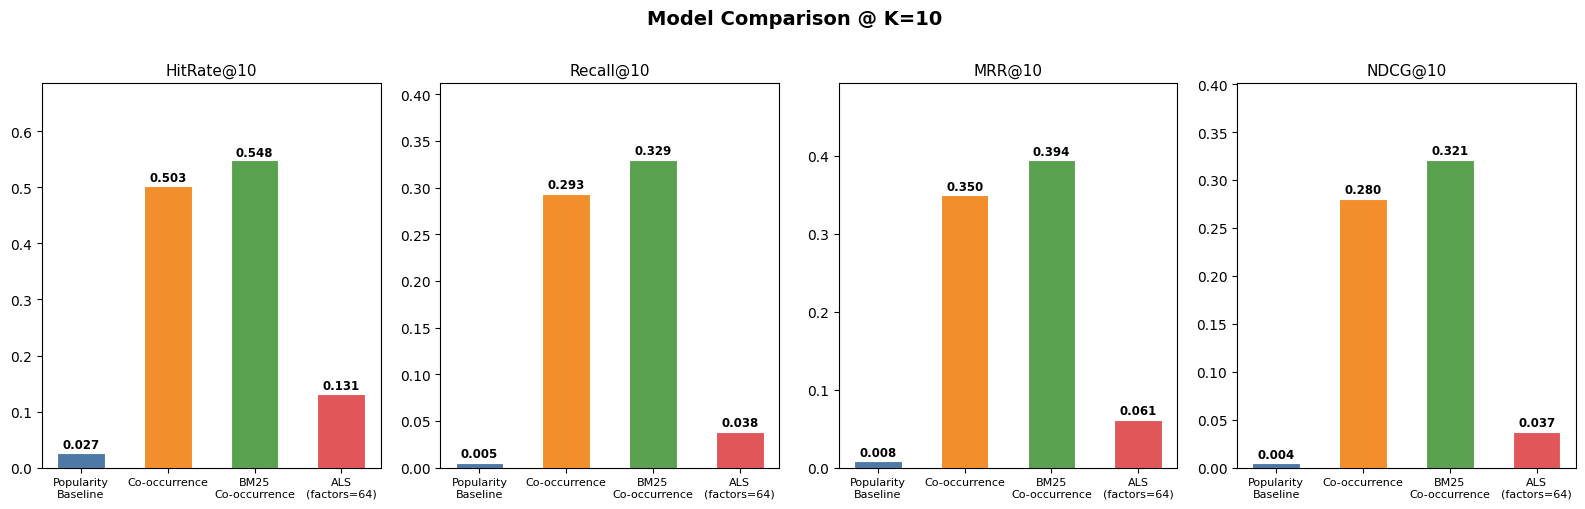

In [25]:
# Plot 1 — Bar chart @ K=10
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Model Comparison @ K=10", fontsize=14, fontweight="bold", y=1.01)

for ax, metric in zip(axes, METRICS):
    vals = [all_results[m].loc[10, metric] for m in model_names]
    bars = ax.bar(
        model_names, vals,
        color=[MODEL_COLORS[m] for m in model_names],
        edgecolor="white", linewidth=0.8, width=0.55
    )
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{v:.3f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold"
        )
    ax.set_title(f"{metric}@10", fontsize=11)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(" ", "\n") for m in model_names], fontsize=8)
    ax.set_ylim(0, max(vals) * 1.25 if max(vals) > 0 else 0.1)

plt.tight_layout()
plt.savefig("viz_bar_k10.png", dpi=150, bbox_inches="tight")
plt.show()

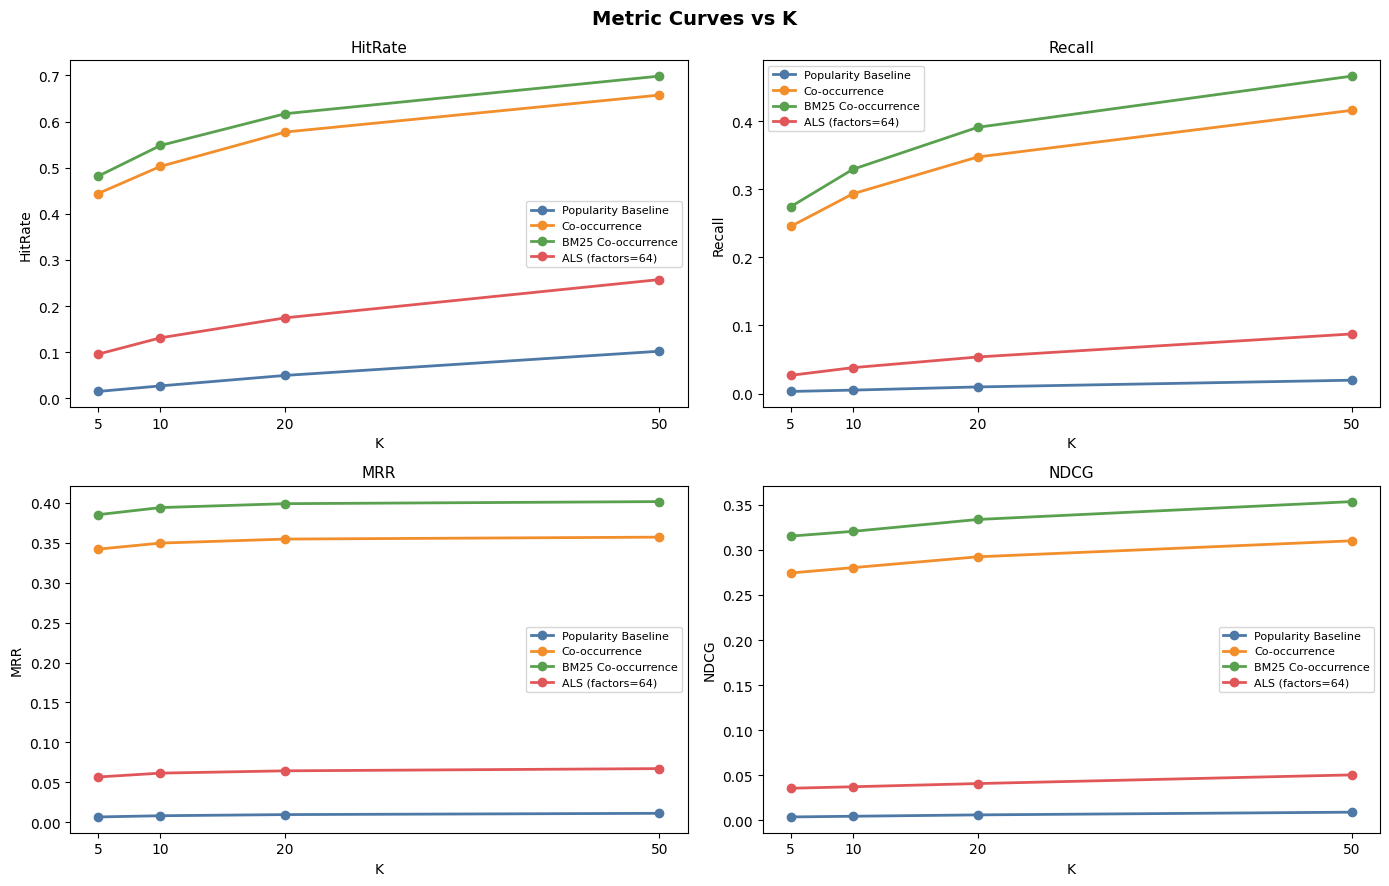

In [26]:
# Plot 2 — Metric curves vs K
k_vals = list(K_VALUES)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Metric Curves vs K", fontsize=14, fontweight="bold")

for ax, metric in zip(axes.flat, METRICS):
    for name in model_names:
        y = [all_results[name].loc[k, metric] for k in k_vals]
        ax.plot(k_vals, y, marker="o", linewidth=2, markersize=6,
                label=name, color=MODEL_COLORS[name])
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_xticks(k_vals)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("viz_metric_curves.png", dpi=150, bbox_inches="tight")
plt.show()

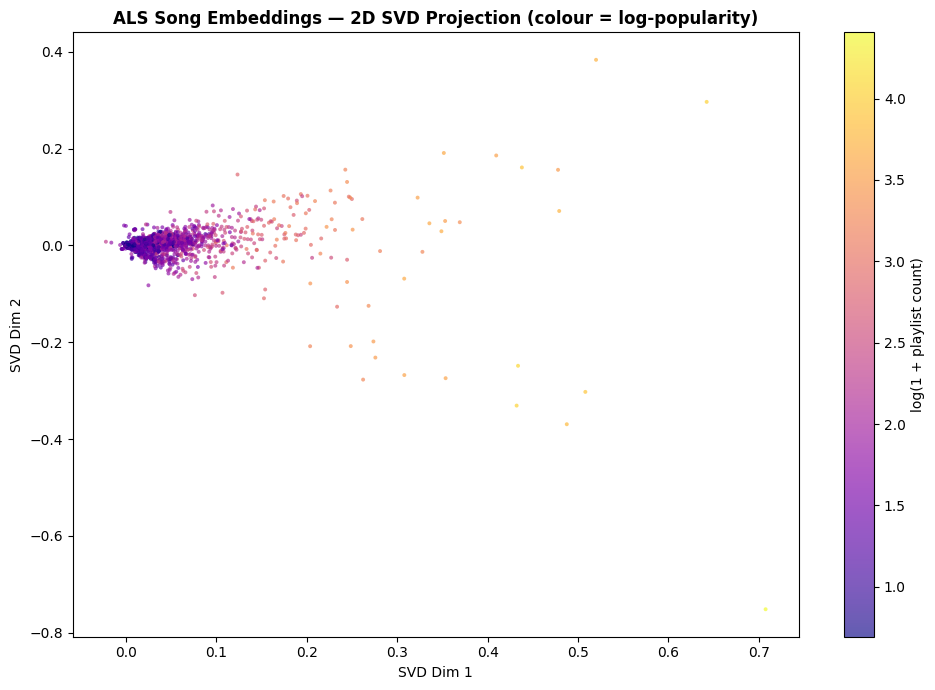

In [27]:
if not RUN_ALS:
    print("ALS latent space plot skipped (RUN_ALS=False)")
else:
    # Plot 3 — ALS latent space (TruncatedSVD -> 2D)
    N_SAMPLE   = min(3000, len(all_song_keys))
    rng        = np.random.default_rng(RANDOM_SEED)
    sample_ids = rng.choice(len(all_song_keys), size=N_SAMPLE, replace=False)

    svd    = TruncatedSVD(n_components=2, random_state=RANDOM_SEED)
    coords = svd.fit_transform(item_factors[sample_ids])

    log_pop = np.array([
        math.log1p(train_song_popularity.get(all_song_keys[i], 0))
        for i in sample_ids
    ])

    fig, ax = plt.subplots(figsize=(10, 7))
    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    c=log_pop, cmap="plasma", s=8, alpha=0.65, linewidths=0)
    plt.colorbar(sc, ax=ax, label="log(1 + playlist count)")
    ax.set_title("ALS Song Embeddings — 2D SVD Projection (colour = log-popularity)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("SVD Dim 1")
    ax.set_ylabel("SVD Dim 2")
    plt.tight_layout()
    plt.savefig("viz_als_latent.png", dpi=150, bbox_inches="tight")
    plt.show()

                     coverage_pct  mean_diversity
Popularity Baseline        0.0374          0.9998
Co-occurrence              5.6840          0.6616
BM25 Co-occurrence         7.0671          0.5690
ALS (factors=64)           1.3293          0.8474


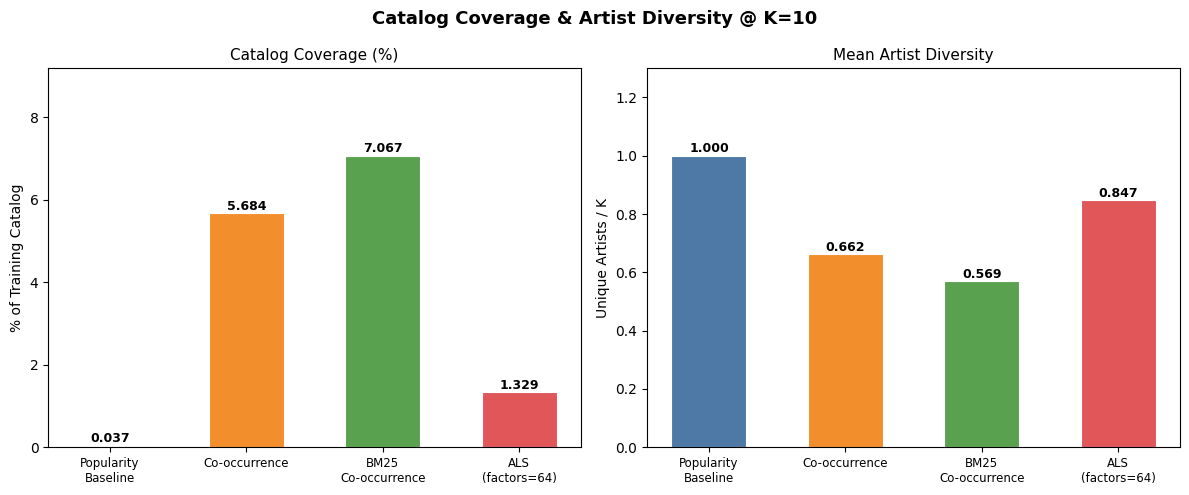

In [28]:
# Plot 4 — Catalog coverage & intra-list artist diversity
EVAL_K      = 10
eval_subset = test_cases[:min(500, len(test_cases))]
song_to_artist = filtered.groupby("song_key")["artist_norm"].first().to_dict()
total_songs    = len({s for songs in train_playlist_to_songs.values() for s in songs})


def coverage_and_diversity(fn, cases, k):
    rec_catalog, diversity_scores = set(), []
    for case in cases:
        recs = fn(case["observed"], topk=k)
        rec_catalog.update(recs)
        artists = [song_to_artist.get(s, "unknown") for s in recs]
        diversity_scores.append(len(set(artists)) / max(len(recs), 1))
    return {
        "coverage_pct"  : 100.0 * len(rec_catalog) / max(total_songs, 1),
        "mean_diversity": float(np.mean(diversity_scores)),
    }


cd_df = pd.DataFrame(
    {name: coverage_and_diversity(fn, eval_subset, EVAL_K) for name, fn in models.items()}
).T
print(cd_df.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Catalog Coverage & Artist Diversity @ K={EVAL_K}",
             fontsize=13, fontweight="bold")

for ax, col, ylabel, title in [
    (axes[0], "coverage_pct",   "% of Training Catalog", "Catalog Coverage (%)"),
    (axes[1], "mean_diversity",  "Unique Artists / K",   "Mean Artist Diversity"),
]:
    vals  = cd_df[col].values
    names = cd_df.index.tolist()
    bars  = ax.bar(names, vals,
                   color=[MODEL_COLORS[m] for m in names],
                   edgecolor="white", linewidth=0.8, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001 * max(vals),
                f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=8.5)
    ax.set_ylim(0, max(vals) * 1.3 if max(vals) > 0 else 1)

plt.tight_layout()
plt.savefig("viz_coverage_diversity.png", dpi=150, bbox_inches="tight")
plt.show()

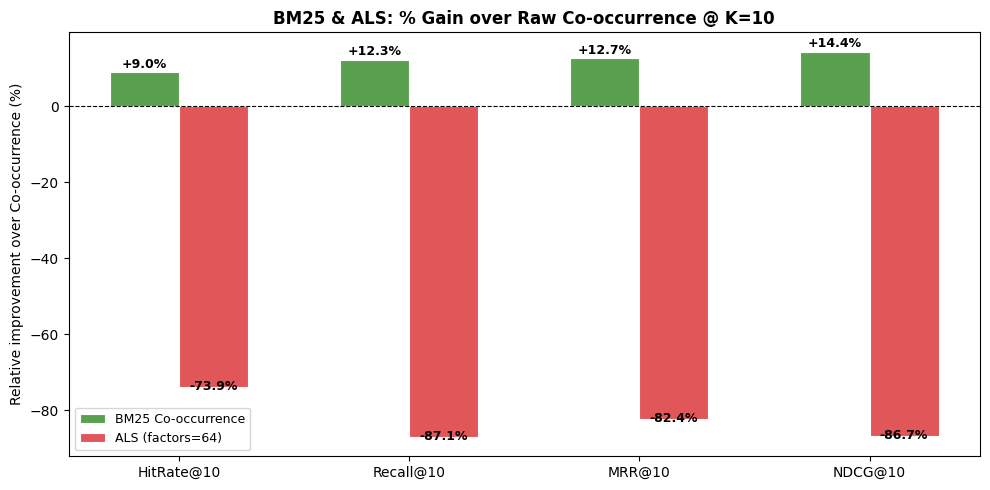

In [29]:
_baseline_key = "Co-occurrence"
_compare_keys = [m for m in ["BM25 Co-occurrence", "ALS (factors=64)"] if m in all_results]

if _baseline_key not in all_results or not _compare_keys:
    print("Relative gain plot skipped — need Co-occurrence + at least one of BM25 / ALS in all_results.")
else:
    # Plot 5 — Relative % gain of BM25 & ALS over Co-occurrence @ K=10
    comp_colors = {"BM25 Co-occurrence": "#59a14f", "ALS (factors=64)": "#e15759"}

    rel_data = {
        name: {
            metric: (all_results[name].loc[10, metric] - all_results[_baseline_key].loc[10, metric])
                    / max(all_results[_baseline_key].loc[10, metric], 1e-9) * 100
            for metric in METRICS
        }
        for name in _compare_keys
    }

    fig, ax = plt.subplots(figsize=(10, 5))
    x, width = np.arange(len(METRICS)), 0.3

    for i, name in enumerate(_compare_keys):
        vals   = [rel_data[name][m] for m in METRICS]
        offset = (i - 0.5) * width
        bars   = ax.bar(x + offset, vals, width, label=name,
                        color=comp_colors[name], edgecolor="white", linewidth=0.8)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.3 if v >= 0 else -1.5),
                    f"{v:+.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{m}@10" for m in METRICS], fontsize=10)
    ax.set_ylabel("Relative improvement over Co-occurrence (%)")
    ax.set_title("BM25 & ALS: % Gain over Raw Co-occurrence @ K=10",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("viz_relative_gain.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Qualitative Examples

In [30]:
def pretty(s):
    return song_display_map.get(s, s)

for i, case in enumerate(test_cases[:3], start=1):
    obs, hidden = case["observed"], case["hidden"]
    print(f"{'='*70}")
    print(f"Example {i}")
    print(f"  Observed ({len(obs)}): {', '.join(pretty(s) for s in obs[:5])}{'...' if len(obs)>5 else ''}")
    print(f"  Hidden   ({len(hidden)}): {', '.join(pretty(s) for s in hidden)}")
    print()
    for name, fn in models.items():
        recs    = fn(obs, topk=5)
        hits    = hidden & set(recs)
        hit_str = f"  HIT: {', '.join(pretty(s) for s in hits)}" if hits else ""
        print(f"  {name:<25}: {', '.join(pretty(s) for s in recs[:5])}{hit_str}")
    print()

Example 1
  Observed (9): Panic! At the Disco — Time to Dance, Panic! at the Disco — London Beckoned Songs About Money Written By Machines, Panic! At The Disco — The Only Difference Between Martyrdom and Suicide is Press Coverage, Panic! at the Disco — But It's Better If You Do, Panic! at the Disco — I Write Sins Not Tragedies...
  Hidden   (2): Panic! at the Disco — Camisado, Panic! At The Disco — There's A Good Reason These Tables Are Numbered Honey, You Just Haven't Thought Of It Yet

  Popularity Baseline      : M83 — Midnight City, Bastille — Pompeii, Of Monsters and Men — Little Talks, Avicii — Wake Me Up, Clean Bandit — Rather Be (feat. Jess Glynne)
  Co-occurrence            : Paramore — Misery Business, Owl City — Fireflies, Paramore — crushcrushcrush, Fall Out Boy — Thnks fr th Mmrs, Adele — Rolling In The Deep
  BM25 Co-occurrence       : Panic! At The Disco — Nine In The Afternoon, Paramore — Misery Business, Fall Out Boy — Thnks fr th Mmrs, Green Day — Good Riddance [Time 

## 8. Summary

| Model | Key Idea | Speed |
|---|---|---|
| Popularity Baseline | Globally most popular songs | O(1) per query |
| Co-occurrence | Raw playlist co-occurrence counts | O(obs x playlists) |
| BM25 Co-occurrence | Length-normalized, TF-saturated co-occurrence | O(obs x playlists) |
| ALS (factors=64) | Latent factor model, dot-product retrieval | O(n_songs x d) |

### Next Steps
- **User-level pooling**: aggregate songs across a user's other playlists for richer ALS input
- **Hybrid fusion**: `score = a*ALS + b*BM25`, tuned on a validation split
- **Content features**: Spotify audio features (tempo, danceability, valence) as ALS side-information